# <a id='toc1_'></a>[REGRESIÓN LOGÍSTICA](#toc0_)

Se aplica cuando tenemos que analizar un conjunto de datos cuya salida/objetivo es discreto (no contínuo), y permite modelar las probabilidades de problemas de clasificación con dos resultados posibles (binario). Es por ello que decimos que el resultado es **discreto o categórico** (SI/NO, 0/1, TRUE/FALSE)

En el siguiente problema se intenta predecir si una flor del dataset IRIS pertenece o no (clasificación binaria) a un determinado tipo.

**Tabla de contenidos**<a id='toc0_'></a>    
- [REGRESIÓN LOGÍSTICA](#toc1_)    
  - [Graficado de la frontera de decisión](#toc1_1_)    
    - [-Importamos las librerías a utilizar](#toc1_1_1_)    
    - [-Cargamos el dataset](#toc1_1_2_)    
    - [-Creamos y entrenamos el modelo](#toc1_1_3_)    
    - [-Realizamos predicciones y estimamos probabilidades](#toc1_1_4_)    
    - [-Graficamos los resultados, mostrando la frontera de decisión](#toc1_1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Graficado de la frontera de decisión](#toc0_)

Partiendo del dataset iris del paquete scikit-learn, vamos a usar un modelo de regresión logística para predecir si una flor es de tipo "VIRGÍNICA" en función de la anchura del pétalo

### <a id='toc1_1_1_'></a>[-Importamos las librerías a utilizar](#toc0_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### <a id='toc1_1_2_'></a>[-Cargamos el dataset](#toc0_)

In [2]:
iris = load_iris()
 
X = iris.data[:, 3:] # petal width
y = (iris.target == 2).astype(int)

In [3]:
# Visualización del conjunto de datos - Primeros 5 registros
print("Features: ", iris.feature_names)
print(iris.data[:5])
print("Target: ")
print(iris.target[:5])

Features:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Target: 
[0 0 0 0 0]


In [4]:
print("X (petal lenght(cm)) : Valores entre ", X.min()," y ", X.max())

X (petal lenght(cm)) : Valores entre  0.1  y  2.5


### <a id='toc1_1_3_'></a>[-Creamos y entrenamos el modelo](#toc0_)

In [5]:
log_reg = LogisticRegression()
 
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

### <a id='toc1_1_4_'></a>[-Realizamos predicciones y estimamos probabilidades](#toc0_)

In [6]:
# Crea un array NumPy con 1000 valores espaciados uniformemente entre 0 y 3 (longitud de los pétalos)
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
# Calcula la probabilidad de que cada flor del nuevo conjunto X_new sea Iris-Virginica
y_proba = log_reg.predict_proba(X_new)

In [7]:
# Características de la predicción
# X not virginica e Y no virginica
X_not_virg = X[0:100, :]  # Primeras 100 filas contiene las características de las flores que no son virginica
y_not_virg = y[0:100]
# X virginica e Y virginica
X_virg = X[100:, :] # Resto de las filas contiene las características de las flores que son virginica (50)
y_virg = y[100:]

### <a id='toc1_1_5_'></a>[-Graficamos los resultados, mostrando la frontera de decisión](#toc0_)

Text(0.5, 1.0, 'Probabilidades estimadas y fronteras de decisión')

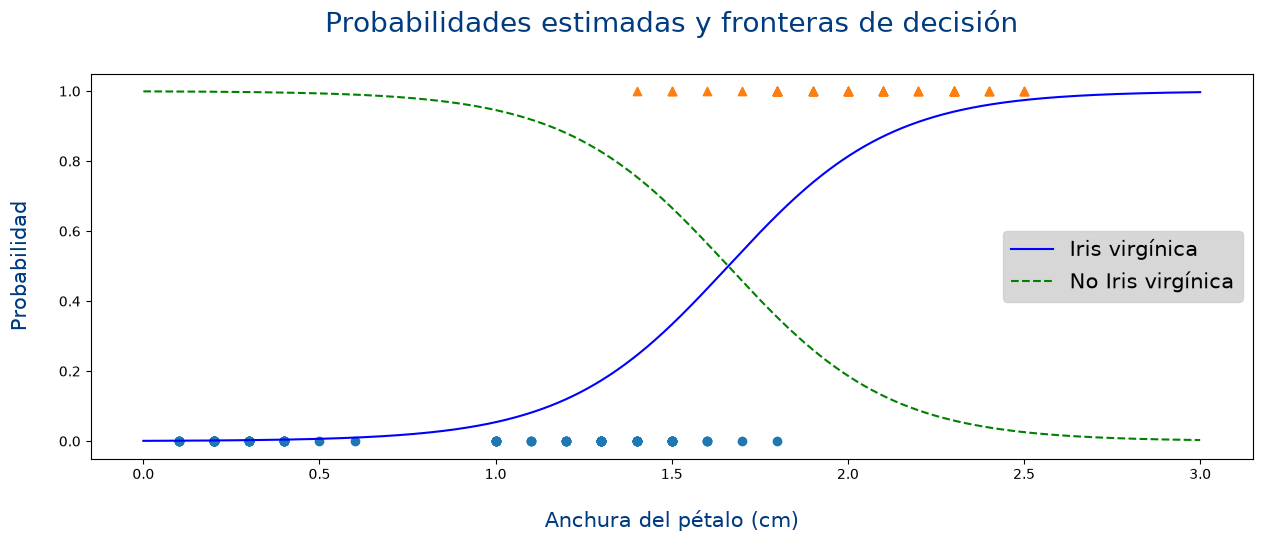

In [8]:
figure=plt.figure(figsize=(15, 5))
axes = figure.add_subplot()
axes.plot(X_new, y_proba[:, 1], "b-", label = "Iris virgínica")
axes.plot(X_new, y_proba[:, 0], "g--", label = "No Iris virgínica")
axes.scatter(X_not_virg, y_not_virg)
axes.scatter(X_virg, y_virg, marker = "^")
axes.legend(fontsize=15,facecolor='#CDCDCD',labelcolor="#000000")
axes.set_xlabel('Anchura del pétalo (cm)', fontsize=15,labelpad=20,color="#003B80") 
axes.set_ylabel('Probabilidad', fontsize=15,labelpad=20,color="#003B80") 
axes.set_title("Probabilidades estimadas y fronteras de decisión", fontsize=20,pad=30,color="#003B80") 

Como vemos, la anchura de las flores iris virgínica va desde 1.4 hasta 2.5 cm, mientras que las otras flores tienen, por lo general, una anchura de pétalo más pequeña. Hay un cierto solapamiento en los datos: por encima de 2cm, el modelo está bastante seguro que es virgínica, mientras que por debajo de 1 cm está bastante seguro que no lo es. En medio de estos extremos, el clasificador no está del todo seguro. Hay un límite de decisión alrededor de 1.6 cm donde ambas probabilidades son iguales al 50%.

## EVALUACIÓN DEL MODELO

### PRECISIÓN (ACCURACY)

Proporción de predicciones correctas realizadas con respecto al número total de predicciones:   

<center>Precisión = (Número de predicciones correctas) / (Número total de predicciones)</center>

In [9]:
from sklearn.metrics import accuracy_score
acc= accuracy_score(y, log_reg.predict(X))
print ("Precisión del modelo: ", acc*100, "%")


Precisión del modelo:  96.0 %


#### MATRIZ DE CONFUSIÓN  

In [10]:
from sklearn.metrics import confusion_matrix
print("Matriz de confusión: ")
print(confusion_matrix(y, log_reg.predict(X)))

Matriz de confusión: 
[[98  2]
 [ 4 46]]


La matriz de confusión nos muestra en su primera columna la predicción de la clase "No virgínica" y en la segunda la predicción de la  clase "Virgínica". En su primera fila están la información de las flores "No vírginica" reales y en la segunda fila las flores "Virgínica" reales.   
Por tanto, de 100 ejemplares reales "No virgínica" clasifica bien 98 y mal 2. De 50 ejemplares reales "virgínica" clasifica bien 46 y mal 4.

#### INFORME DE CLASIFICACIÓN

In [11]:
print("Informe de clasificación: ")
from sklearn.metrics import classification_report
print(classification_report(y, log_reg.predict(X)))

Informe de clasificación: 
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       100
           1       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.96      0.96       150



#### Métricas por clase:

- Precisión (precision):
  - Clase 0: 0.96. De todas las instancias que el modelo predijo como clase 0, el 96% eran realmente de la clase 0.
  - Clase 1: 0.96. De todas las instancias que el modelo predijo como clase 1, el 96% eran realmente de la clase 1.
- Exhaustividad (recall):
  - Clase 0: 0.98. De todas las instancias que realmente eran de la clase 0, el modelo identificó correctamente el 98%.
  - Clase 1: 0.92. De todas las instancias que realmente eran de la clase 1, el modelo identificó correctamente el 92%.
- Puntuación F1 (f1-score):
  - Clase 0: 0.97. Es una medida que combina precisión y exhaustividad. Un valor alto indica un buen equilibrio entre ambas.
  - Clase 1: 0.94.
- Soporte (support):
  - Clase 0: 100. Indica el número de instancias de la clase 0 en el conjunto de datos.
  - Clase 1: 50. Indica el número de instancias de la clase 1 en el conjunto de datos.

#### Métricas globales:

- Exactitud (accuracy): 0.96. El modelo clasificó correctamente el 96% de todas las instancias en el conjunto de datos.
- Macro promedio (macro avg): Calcula el promedio de las métricas (precisión, exhaustividad, puntuación F1) para cada clase, sin tener en cuenta el número de instancias en cada clase.
- Promedio ponderado (weighted avg): Calcula el promedio de las métricas para cada clase, teniendo en cuenta el número de instancias en cada clase (es decir, ponderado por el soporte).

En general, este informe indica que el modelo tiene un buen rendimiento en ambas clases, con una precisión y exhaustividad altas. La puntuación F1 también es alta, lo que indica un buen equilibrio entre precisión y exhaustividad.

## EJEMPLO REGRESIÓN LOGÍSTICA MÚLTIPLE - Clasificación de correo
### (usando la API de StatsModels)  

El set de datos `spam`, obtenido de **UCI Repository Of Machine Learning Databases** contiene información sobre 4601 correos electrónicos clasificados como *spam* y *no spam*.

Para cada correo electrónico se dispone de 58 variables:    
- Las 48 primeras contienen la frecuencia con la que aparecen en el texto del email determinadas palabras. 
- Las variables 49-54 indican la frecuencia con la que aparecen los caracteres ;’, ‘(’, ‘[’, ‘!’, ‘$’, ‘#’. 
- Las variables 55-57 contienen la media, a longitud máxima y el número total de letras mayúsculas.

Se quiere crear un modelo de **regresión logística** con el objetivo de clasificar si un correo es spam o no.

### Carga de librerías

In [2]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocesado y modelado
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Datos
# ==============================================================================
url = (
    'https://raw.githubusercontent.com/JoaquinAmatRodrigo/'
    'Estadistica-machine-learning-python/master/data/spam.csv'
)
datos = pd.read_csv(url)
datos.head(3)


,make,address,all,num3d,our,over,remove,internet,order,mail,...,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal,type
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,spam
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,spam
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,spam


Se codifica la variable respuesta como 1 si es spam y 0 si no lo es, y se identifica cuantas observaciones hay de cada clase.



In [4]:
datos['type'] = np.where(datos['type'] == 'spam', 1, 0)

print("Número de observaciones por clase")
print(datos['type'].value_counts())
print("")

print("Porcentaje de observaciones por clase")
print(100 * datos['type'].value_counts(normalize=True))


Número de observaciones por clase
type
0    2788
1    1813
Name: count, dtype: int64

Porcentaje de observaciones por clase
type
0    60.595523
1    39.404477
Name: proportion, dtype: float64


El 66.6% de los correos no son spam y el 39.4% sí lo son. Un modelo de clasificación que sea útil debe de ser capaz de predecir correctamente un porcentaje de observaciones por encima del porcentaje de la clase mayoritaria. En este caso, el umbral de referencia que se tiene que superar es del 66.6%.

## Ajuste del modelo

Se ajusta un modelo de regresión logística múltiple con el objetivo de predecir si un correo es spam en función de todas las variables disponibles.

In [5]:
# División de los datos en train y test
# ==============================================================================
X = datos.drop(columns = 'type')
y = datos['type']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values,
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )


In [ ]:
# Creación de un modelo de regresión logística con statsmodels
# ==============================================================================
# statsmodels no añade automáticamente el intercepto al utilizar la API matricial.
# Se añade una columna constante de 1s a X_train para poder estimar beta_0(intercepto).

X_train = sm.add_constant(X_train, prepend=True) 

# Se define el modelo:
#   endog -> variable objetivo o dependiente
#   exog  -> variables predictoras o independientes

modelo = sm.Logit(endog=y_train, exog=X_train,)

# Se ajusta el modelo mediante máxima verosimilitud,
# estimando los coeficientes beta_0, beta_1, ..., beta_n.

modelo = modelo.fit()

# Se muestra un resumen estadístico completo del modelo ajustado.
print(modelo.summary())


Optimization terminated successfully.
         Current function value: 0.200751
         Iterations 15
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 3680
Model:                          Logit   Df Residuals:                     3622
Method:                           MLE   Df Model:                           57
Date:                mié, 07 oct 2026   Pseudo R-squ.:                  0.7009
Time:                        10:29:44   Log-Likelihood:                -738.76
converged:                       True   LL-Null:                       -2469.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.5530      0.156     -9.956      0.000      -1.859      -1.247
make   

## Predicciones
Una vez entrenado el modelo, se pueden obtener predicciones para nuevos datos. Los modelos de statsmodels permiten calcular los intervalos de confianza asociados a cada predicción.

In [ ]:
# Predicciones con intervalo de confianza 
# ==============================================================================
predicciones = modelo.predict(exog = X_train)

# Clasificación predicha
# ==============================================================================
# buscamos que las predicciones sean menores que 0.5, si es así, se clasifica como 0, si no, se clasifica como 1
clasificacion = np.where(predicciones<0.5, 0, 1) 
clasificacion


array([0, 0, 0, ..., 1, 1, 0], shape=(3680,))

### Evaluación del modelo

#### Accuracy (Porcentaje de aciertos en predicción de observaciones del conjunto de test)



In [8]:
# Accuracy del modelo 
# ==============================================================================
X_test = sm.add_constant(X_test, prepend=True)
predicciones = modelo.predict(exog = X_test)
clasificacion = np.where(predicciones<0.5, 0, 1)
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = clasificacion,
            normalize = True
           )
print("")
print(f"Accuracy: {100*accuracy}%")



Accuracy: 92.83387622149837%


In [9]:
# Matriz de confusión de las predicciones de test
# ==============================================================================
confusion_matrix = pd.crosstab(
    y_test.ravel(),
    clasificacion,
    rownames=['Real'],
    colnames=['Predicción']
)
confusion_matrix


Predicción,0,1
Real,,
0,535,28
1,38,320


### Conclusión

El modelo logístico creado para predecir la probabilidad de que un correo sea spam es en conjunto significativo (Likelihood ratio p-value = 0). El porcentaje de clasificación correcta en el conjunto del test es del 92.8%, un valor muy por encima del umbral de 66.6% esperado por azar.

Acorde al p-value individual de cada predictor, solo algunos de ellos aportan información al modelo. Es conveniente identificar cuáles son y excluirlos para simplificar el modelo y evitar la introducción de ruido. Una forma de conseguir reducir la influencia de predictores que no aportan a un modelo de regresión logística es incorporar regularización en su ajuste.